In [1]:
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd

import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm

In [7]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)

In [18]:
energyDF

,Basis Set,Molecule,Method,Energy
0,STO-3G,water,HF,-74.960552
1,STO-3G,water,CCSD,-75.009350
2,STO-3G,water,CASCI,-75.009479
3,STO-3G,water,SHCI,-75.009474
4,STO-3G,ammonia,HF,-55.454318
...,...,...,...,...
139,aug-cc-pVDZ,GDB04_65,SHCI,-216.171693
140,aug-cc-pVDZ,GDB04_5,HF,-336.812790
141,aug-cc-pVDZ,GDB04_5,CCSD,-337.583137
142,aug-cc-pVDZ,GDB04_5,CASCI,-336.812913


In [19]:
postprocessed = []
for i in tqdm(glob("./energies/*txt"),desc='Running'):
    with open(i,'r') as f:
        moldict = pd.DataFrame.from_dict(dict(zip(["Basis Set","Molecule","Method","Energy"],[i.strip() for i in f.readlines()])),orient='index').T
        postprocessed.append(moldict)

Running:   0%|          | 0/4 [00:00<?, ?it/s]

In [25]:
upDF = pd.concat([energyDF,pd.concat(postprocessed)]).reset_index().drop(columns=['index'])

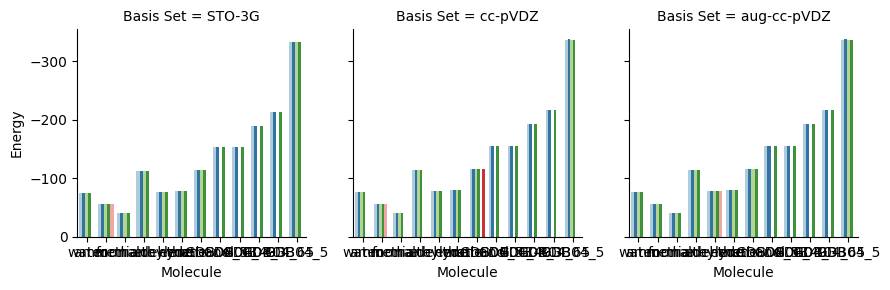

In [28]:
g = sns.FacetGrid(upDF, col="Basis Set")
g.map_dataframe(sns.barplot, x="Molecule",y='Energy',hue='Method',palette="Paired")

In [26]:
upDF

,Basis Set,Molecule,Method,Energy
0,STO-3G,water,HF,-74.960552
1,STO-3G,water,CCSD,-75.00935
2,STO-3G,water,CASCI,-75.009479
3,STO-3G,water,SHCI,-75.009474
4,STO-3G,ammonia,HF,-55.454318
...,...,...,...,...
143,aug-cc-pVDZ,GDB04_5,SHCI,-336.927601
144,STO-3G,ammonia,LUCJ(L=1),-55.51992920379548
145,cc-pVDZ,ammonia,LUCJ(L=5),-56.20672830636165
146,aug-cc-pVDZ,ethylene,LUCJ(L=1),-78.04539687832205
